At its core, the question wants you to:

Build and use a simple Perceptron model to classify data into two classes, where the data can be separated by a straight line.

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler

In [23]:
data= pd.read_csv("c:\\Users\\user\\Downloads\\placement.csv")

In [24]:
print("the description of the our data is... ", data.describe())
print("the info of the our data is... ", data.info())
print("There are total of", len(data), "rows in our data")
print("these are the columns:", data.columns)

the description of the our data is...                cgpa  placement_exam_marks       placed
count  1000.000000           1000.000000  1000.000000
mean      6.961240             32.225000     0.489000
std       0.615898             19.130822     0.500129
min       4.890000              0.000000     0.000000
25%       6.550000             17.000000     0.000000
50%       6.960000             28.000000     0.000000
75%       7.370000             44.000000     1.000000
max       9.120000            100.000000     1.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   cgpa                  1000 non-null   float64
 1   placement_exam_marks  1000 non-null   float64
 2   placed                1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB
the info of the our data is...  None
There are total of 1000 row

In [25]:
data.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


In [26]:
x = data.iloc[:, 0:2]
y = data.iloc[:, -1]

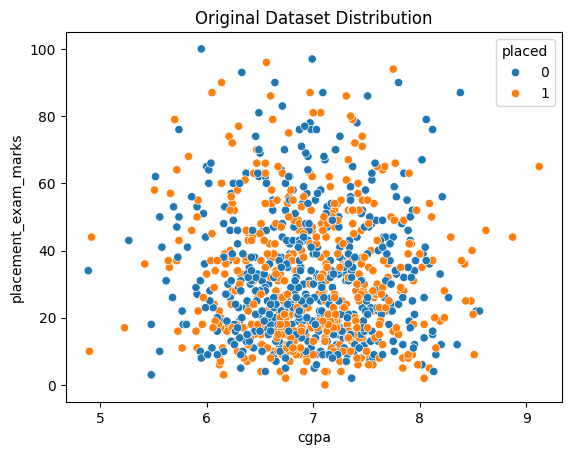

In [27]:
sns.scatterplot(x=x.iloc[:,0], y=x.iloc[:,1], hue=y)
plt.title("Original Dataset Distribution")
plt.show()

In [28]:
p = Perceptron(max_iter=1500, tol=1e-4, random_state=42)

In [ ]:
#x_scaled = StandardScaler().fit_transform(x)

In [46]:
p.fit(x, y)
#p.fit(x_scaled, y)

,penalty,None
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1500
,tol,0.0001
,shuffle,True
,verbose,0
,eta0,1.0
,n_jobs,None
,random_state,42


In [47]:
print("Learned Weights (coef_): ", p.coef_)

Learned Weights (coef_):  [[32.32 40.  ]]


In [48]:
print("Learned Bias (intercept_): ", p.intercept_)

Learned Bias (intercept_):  [-6.]


In [49]:
accuracy = p.score(x, y)
                   #accuracy = p.score(x_scaled, y)

In [50]:
print("The accuracy is ", accuracy)

The accuracy is  0.489


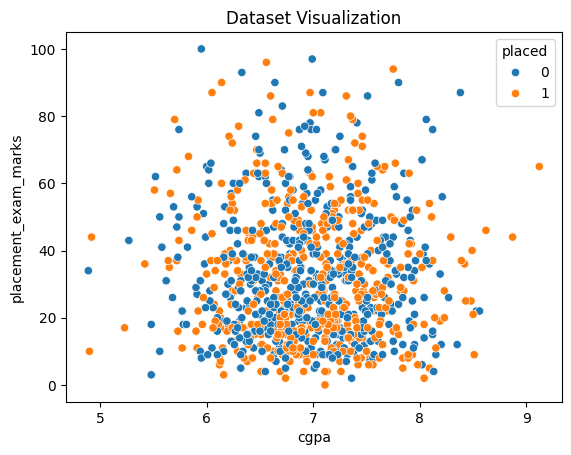

In [51]:
sns.scatterplot(
    x=x.iloc[:,0],
    y=x.iloc[:,1],
    hue=y
)

plt.title("Dataset Visualization")
plt.show()

The visualization shows:

massive overlap between class 0 and class 1,
no visible straight-line separation,
both classes occupying nearly the same feature space.

A perceptron is therefore the wrong tool.

What The Plot Is Telling

Using:
cgpa
placement_exam_marks

to predict:

placed

But visually:

students with high CGPA appear in BOTH classes,
students with low marks appear in BOTH classes,
no clear geometric boundary exists.



But the data does not admit a useful straight-line separator.

So the perceptron oscillates around mediocre solutions and lands near random accuracy (~50%).


This is a model assumption failure.

Critical distinction.


The issue is:

Reality

=Perceptron Assumption

Perceptron assumes:

linearly separable classes

linearly separable classes

Your dataset violates that assumption.

The Deeper ML Lesson

This is exactly why modern ML evolved beyond perceptrons.

Single-layer perceptrons fail on:

overlapping data,
nonlinear relationships,
noisy classification problems.

This limitation historically led to:

multilayer neural networks,
backpropagation,
nonlinear kernels,
deep learning.